In [34]:
from datasets import load_from_disk
from collections import Counter
import matplotlib.pyplot as plt

In [35]:
path ='/home/elena/emcomm/emcomm_captions/checkpoints/winoground_100_eval_best_max_val_10_len_99th_epoch_orig/messages/coco_val_message_captions_3_distractors'
# path = '/home/elena/emcomm/emcomm_captions/checkpoints/3_distractors_proper/messages/coco_val_message_captions_3_distractors'

In [36]:
ds = load_from_disk(path)
ds

Dataset({
    features: ['coco_url', 'captions', 'image_id', 'features', 'message', 'message_truncated'],
    num_rows: 5000
})

In [37]:
msgs = ds['message_truncated']

In [38]:
len(set([item for sublist in msgs for item in sublist]))

30

In [39]:
len(set([str(m) for m in msgs]))

4053

In [40]:
bigrams = Counter()
for msg in msgs:
    for i in range(len(msg) - 1):
        bigrams[(msg[i], msg[i+1])] += 1

# Number of unique bigrams
num_unique_bigrams = len(bigrams)
print("Unique bigrams:", num_unique_bigrams)

# Optional: top bigrams
print("Top bigrams:", bigrams.most_common(5))

Unique bigrams: 306
Top bigrams: [((68, 39), 2589), ((24, 24), 2082), ((2, 68), 1975), ((4, 68), 1564), ((24, 2), 1438)]


In [41]:
all_tokens = [token for msg in msgs for token in msg]

# Count unique unigrams
unique_unigrams = set(all_tokens)
num_unique_unigrams = len(unique_unigrams)

print("Unique unigrams:", num_unique_unigrams)
print("Unigrams:", unique_unigrams)
print("Top unirams:", bigrams.most_common(5))

Unique unigrams: 30
Unigrams: {2, 4, 7, 8, 9, 10, 11, 13, 16, 19, 20, 22, 24, 26, 29, 30, 33, 35, 36, 37, 38, 39, 41, 45, 48, 54, 56, 57, 59, 68}
Top unirams: [((68, 39), 2589), ((24, 24), 2082), ((2, 68), 1975), ((4, 68), 1564), ((24, 2), 1438)]


In [42]:
messages = msgs

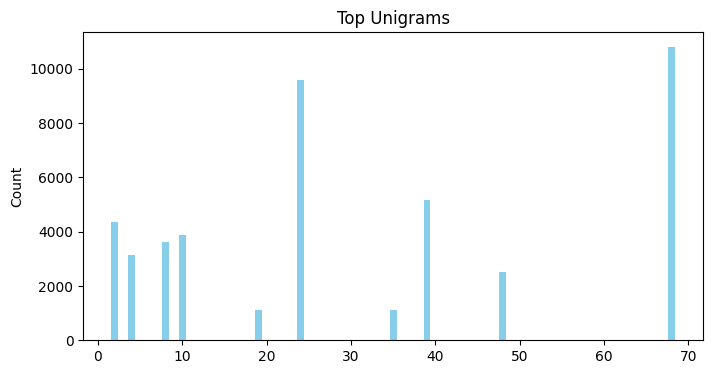

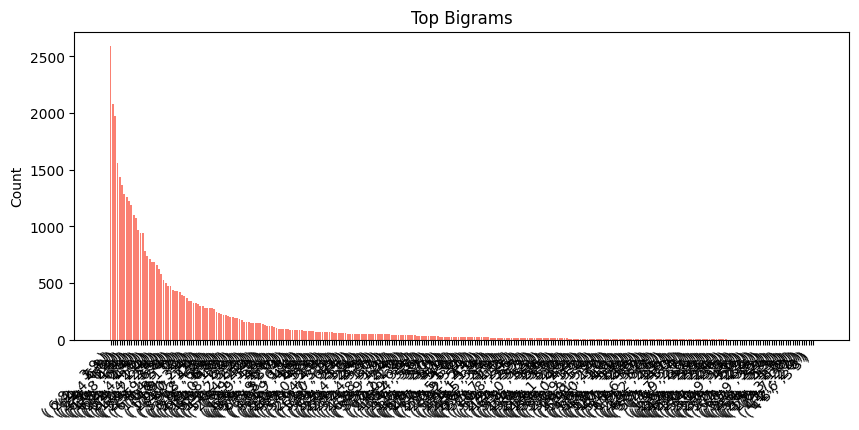

In [43]:
unigrams = Counter(token for msg in messages for token in msg)
top_unigrams = unigrams.most_common(10)  # top 10

# Plot unigrams
plt.figure(figsize=(8, 4))
tokens, counts = zip(*top_unigrams)
plt.bar(tokens, counts, color='skyblue')
plt.title("Top Unigrams")
plt.ylabel("Count")
plt.show()

# --- Bigrams ---
bigrams = Counter()
for msg in messages:
    for i in range(len(msg) - 1):
        bigrams[(msg[i], msg[i+1])] += 1
top_bigrams = bigrams.most_common()  # top 10

# Convert bigram tuples to strings for plotting
bigram_labels = [" ".join(str(bg)) for bg, _ in top_bigrams]
bigram_counts = [count for _, count in top_bigrams]

plt.figure(figsize=(10, 4))
plt.bar(bigram_labels, bigram_counts, color='salmon')
plt.title("Top Bigrams")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

Unique trigrams: 1177


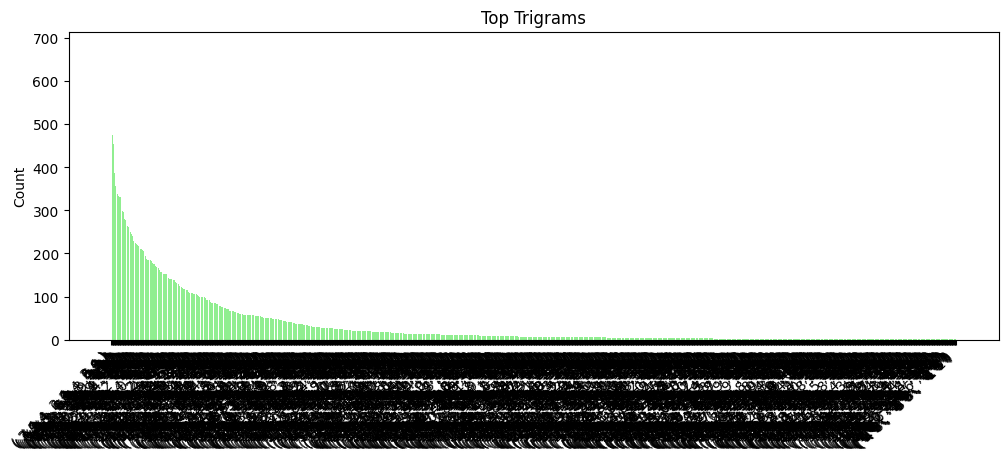

In [ ]:
from collections import Counter
import matplotlib.pyplot as plt

# Example messages
# messages = [
#     ["hello", "world"],
#     ["foo", "bar", "foo"],
#     ["hello", "foo"]
# ]

# --- Trigrams ---
trigrams = Counter()
for msg in messages:
    for i in range(len(msg) - 2):
        trigrams[(msg[i], msg[i+1], msg[i+2])] += 1

top_trigrams = trigrams.most_common()

# Convert trigram tuples to strings for plotting
trigram_labels = [" ".join(str(tg)) for tg, _ in top_trigrams]
trigram_counts = [count for _, count in top_trigrams]

plt.figure(figsize=(12, 4))
plt.bar(trigram_labels, trigram_counts, color='lightgreen')
print("Unique trigrams:", len(trigram_labels))
plt.title("Top Trigrams")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

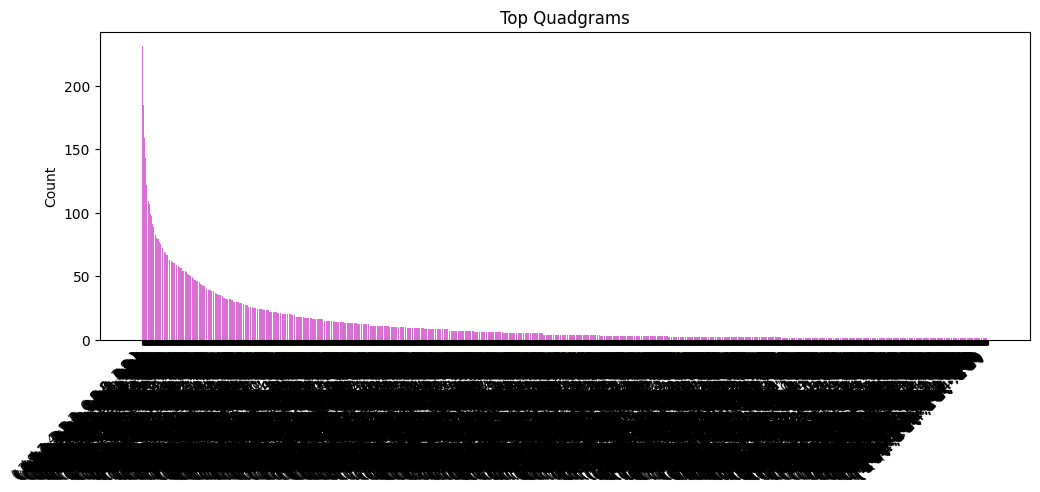

In [45]:
quadgrams = Counter()
for msg in messages:
    for i in range(len(msg) - 3):
        quadgrams[(msg[i], msg[i+1], msg[i+2], msg[i+3])] += 1

top_quadgrams = quadgrams.most_common()

# Convert quadgram tuples to strings for plotting
quad_labels = [" ".join(str(qg)) for qg, _ in top_quadgrams]
quad_counts = [count for _, count in top_quadgrams]

plt.figure(figsize=(12, 4))
plt.bar(quad_labels, quad_counts, color='orchid')
plt.title("Top Quadgrams")
plt.ylabel("Count")
plt.xticks(rotation=45, ha='right')
plt.show()

/home/elena/miniconda/envs/emcomm/lib/python3.12/site-packages/sklearn/feature_extraction/text.py:517: UserWarning: The parameter 'token_pattern' will not be used since 'tokenizer' is not None'
  warnings.warn(


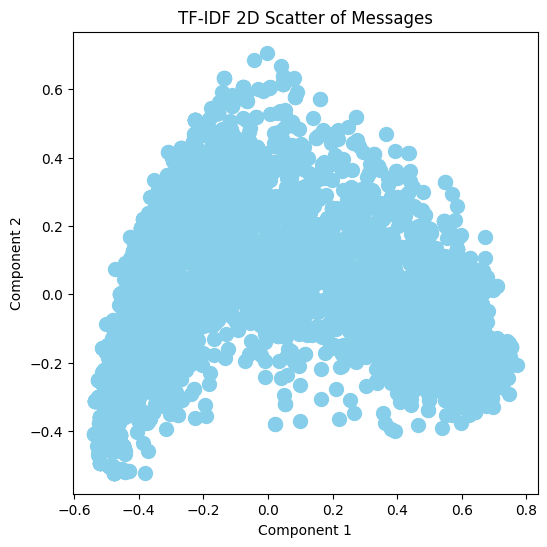

In [54]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
from tqdm import tqdm

# Convert all tokens to strings
messages2 = msgs

messages_str = [[str(token) for token in msg] for msg in messages2]

# Use a custom tokenizer to skip internal tokenization
vectorizer = TfidfVectorizer(tokenizer=lambda x: x, preprocessor=lambda x: x, lowercase=False)
X_tfidf = vectorizer.fit_transform(messages_str)

# Reduce to 2D with PCA
X_2d = PCA(n_components=2).fit_transform(X_tfidf.toarray())

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(X_2d[:, 0], X_2d[:, 1], color='skyblue', s=100)
# for i, msg in tqdm(enumerate(messages_str)):
    # plt.text(X_2d[i, 0]+0.01, X_2d[i, 1]+0.01, " ".join(msg), fontsize=9)
plt.title("TF-IDF 2D Scatter of Messages")
plt.xlabel("Component 1")
plt.ylabel("Component 2")
plt.show()